# Testing RouteLearner class

---

In [2]:
import numpy as np
from main import RouteLearner
import random
from matplotlib import pyplot as plt

np.random.seed(9582735)
random.seed(43875634)

### Helper methods for plotting

In [3]:
def plot_route_map(ax, points, true_lambdas, route, ev_ret, route_time):
    """plot a route on a map of points."""
    route_coords = points[route]  # coords of points in the path
    
    # plot all coords as hollow points
    ax.scatter(points[:, 0], points[:, 1],
               s=true_lambdas * 5,
               facecolors="none",
               edgecolors="gray")
    
    # plot route coords as filled points with size proportional to expected reward
    ax.scatter(route_coords[:, 0], route_coords[:, 1],
               s=true_lambdas[route] * 5,
               color="tab:blue")
    
    # mark start=end node
    ax.scatter(*route_coords[-1],
               color="darkblue", zorder=3)
    
    # connect nodes in the path
    ax.plot(route_coords[:, 0], route_coords[:, 1], "--")

    ax.set_title(f"return={ev_ret:.2f}, time={route_time:.2f}")
    ax.grid(alpha=0.3)


def plot_lambda_scatter(ax, true_lambdas, est_lambdas, title="Parameter recovery", log_x=False):
    """scatter plot of true vs estimated lambdas."""
    ax.scatter(true_lambdas, est_lambdas, alpha=0.7)

    m = max(true_lambdas.max(), est_lambdas.max())

    if log_x:
        low = max(true_lambdas.min(), 1e-10)  # avoid log(0)
        x = np.logspace(np.log10(low), np.log10(m), 300)
        ax.set_xscale("log")
    else:
        x = np.linspace(0, m, 300)

    ax.plot(x, x, "--", color="gray")

    ax.set_xlabel("True lambda")
    ax.set_ylabel("Estimated lambda")
    ax.set_title(title)
    ax.grid(alpha=0.3)

## Initializing hyperparameters and the RouteLearner class

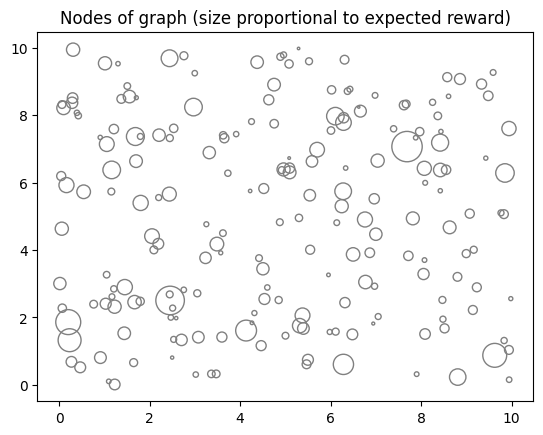

In [4]:
num_nodes = 200
dim = 2
points = np.random.rand(num_nodes, dim)*10
true_lambdas = np.random.lognormal(mean=2, sigma=1, size=num_nodes)
time_window = 40
rl = RouteLearner(points, true_lambdas, time_window)

plt.scatter(rl.points[:, 0], rl.points[:, 1], s=true_lambdas*5, facecolors="none", edgecolors="gray")
plt.title("Nodes of graph (size proportional to expected reward)")
plt.show()

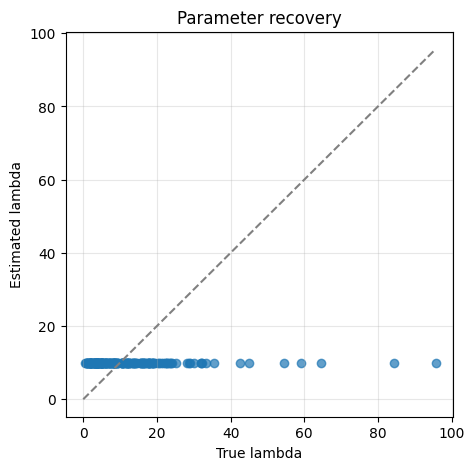

In [5]:
rl.init_priors((1, 0.1))

est_lambdas = rl.ev_estimate()
# print(rl.true_lambdas)
# print(est_lambdas)

fig, ax = plt.subplots(figsize=(5, 5))
plot_lambda_scatter(ax, rl.true_lambdas, est_lambdas)
plt.show()

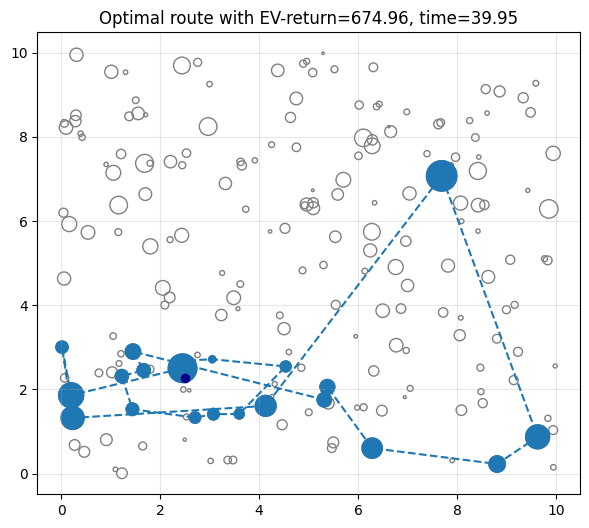

In [6]:
optimal_route, opt_ret = rl.optimal_route(num_samples=20, epsilon=0.05)
# print(optimal_route, opt_ret)
route_coords = points[optimal_route]
# plt.scatter(rl.points[:, 0], rl.points[:, 1], s=true_lambdas*5)
# plt.scatter(*route_coords[-1], color="red", zorder=3, label="End")
# plt.title("Optimal route with return %.2f" % opt_ret)
# plt.plot(route_coords[:, 0], route_coords[:, 1], marker='o')
# plt.show()


fig, ax = plt.subplots(figsize=(7, 6))
time = rl.route_time(optimal_route)
plot_route_map(ax, rl.points, rl.true_lambdas, optimal_route, opt_ret, time)
ax.set_title(f"Optimal route with EV-" + ax.get_title())

plt.show()


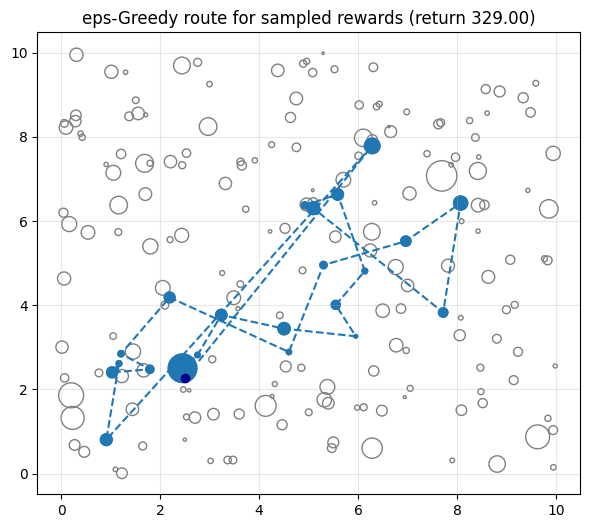

In [7]:
est_route_info = rl.thompson_sample(epsilon=0.05)
est_route = [node for node, _ in est_route_info]
sampled_ret = sum(rew for _, rew in est_route_info)

fig, ax = plt.subplots(figsize=(7, 6))
time = rl.route_time(est_route)
plot_route_map(ax, rl.points, rl.true_lambdas, est_route, sampled_ret, time)
ax.set_title("eps-Greedy route for sampled rewards (return %.2f)" % sampled_ret)

plt.show()

In [8]:
import ipywidgets as widgets

routes = []
est_lambda_hist = []

eps = 0.01
num_days = 100

for t in range(num_days):

    est_ev_route, ev_ret = rl.ev_route()
    routes.append((est_ev_route, ev_ret))

    est_lambda_hist.append(rl.ev_estimate().copy())

    routes_info = rl.thompson_sample(epsilon=eps)
    rl.thompson_update(routes_info)


def plot_route(i):
    est_route, ev_ret = routes[i]
    route_time = rl.route_time(est_route)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    plot_route_map(ax[0], rl.points, rl.true_lambdas, est_route, ev_ret, route_time)
    plot_lambda_scatter(ax[1], rl.true_lambdas, est_lambda_hist[i], log_x=True, title="Parameter recovery (x log-scaled)")
    ax[0].set_title(f"Iteration {i}: " + ax[0].get_title())
    plt.show()
    

widgets.interact(plot_route, i=(0, len(routes)-1));

interactive(children=(IntSlider(value=49, description='i', max=99), Output()), _dom_classes=('widget-interact'…

Interesting notes:
- iteration 31 max-reward node is finally picked
- not every node is explored as can be seen in the parameter recovery plot: their lambda EVs do not change
- scatter plot mostly converged after 38 iterations

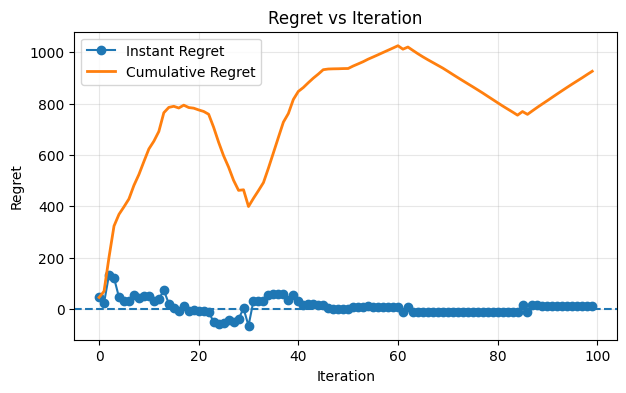

In [9]:
# extract returns from stored routes
ev_returns = np.array([ev_ret for _, ev_ret in routes])

# instantaneous regret
regret = opt_ret - ev_returns
# regret = regret[:40]

# cumulative regret
cum_regret = np.cumsum(regret)

plt.figure(figsize=(7,4))

plt.plot(regret, label="Instant Regret", marker="o")
plt.plot(cum_regret, label="Cumulative Regret", linewidth=2)

plt.axhline(0, linestyle="--")

plt.xlabel("Iteration")
plt.ylabel("Regret")
plt.title("Regret vs Iteration")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Note that regret can easily go negative as the "optimal" route is not really optimal as it was calculated with a few samples of a greedy solver.

Hence, once we start to approximate the true EVs closely, the sampler has more attempts to truly find the optimal route and outperform the initial "optimal" route.

(100,)


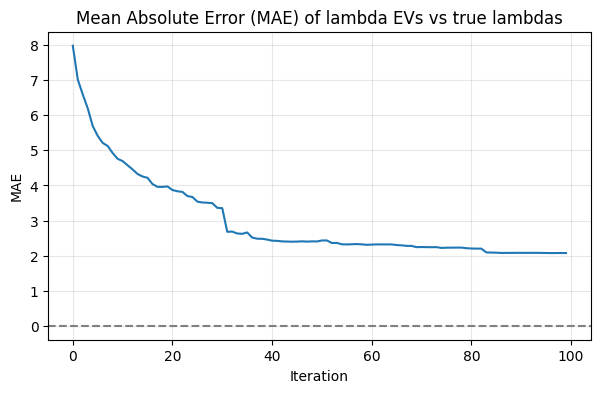

In [10]:
# extract returns from stored routes
ev_history = np.array(est_lambda_hist)

lamb_mae = np.abs(rl.true_lambdas[None, ] - ev_history).mean(axis=-1)
print(lamb_mae.shape)


plt.figure(figsize=(7,4))

plt.plot(lamb_mae)

plt.axhline(0, linestyle="--", color="grey")

plt.xlabel("Iteration")
plt.ylabel("MAE")
plt.title("Mean Absolute Error (MAE) of lambda EVs vs true lambdas")
plt.grid(alpha=0.3)

plt.show()


Does not converge to zero as not all nodes are visited and hence updated. One could also list out the nodes that were updated some amount of times (e.g. look at the beta parameter of `rl.lambs_posterior_params`)